In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Designing a suitable distribution

In [5]:
def _rot_mat (theta, B):
    _theta = np.array(theta)
    return np.moveaxis(np.array([[np.cos(_theta), B*np.sin(_theta)],[-np.sin(_theta)/B, np.cos(_theta)]]),2,0)
def rotation (vec:np.ndarray, theta:float, B:float=1):
    """
    Rotates vector on the plane of an angle theta around an ellipsis with y-oriented axis B times the x-oriented one.
    Input are expected to be np.ndarrays of any shape as long as at leas one dimension ha length two. If more than one
    dimension has length 2, the first is considered to be the spatial dimension.
    """
    if 2 in vec.shape:
        myAx = np.min(np.nonzero(np.array(vec.shape)==2))
        _vec = np.moveaxis(vec, myAx, 0)
        myShape = _vec.shape
        _vec = _vec.reshape((2,-1))
        if np.isscalar(theta):
            rot_mat = _rot_mat(np.full(_vec.shape[1], theta), B)
        else:
            rot_mat = _rot_mat(theta, B)
        res = np.empty_like(_vec)
        for i in range(_vec.shape[1]):
            res[:,i]=_vec[:,i]@rot_mat[i]
        return np.moveaxis(res.reshape(myShape),0,myAx)
    else:
        raise ValueError(f"Invalid input shape {vec.shape}")


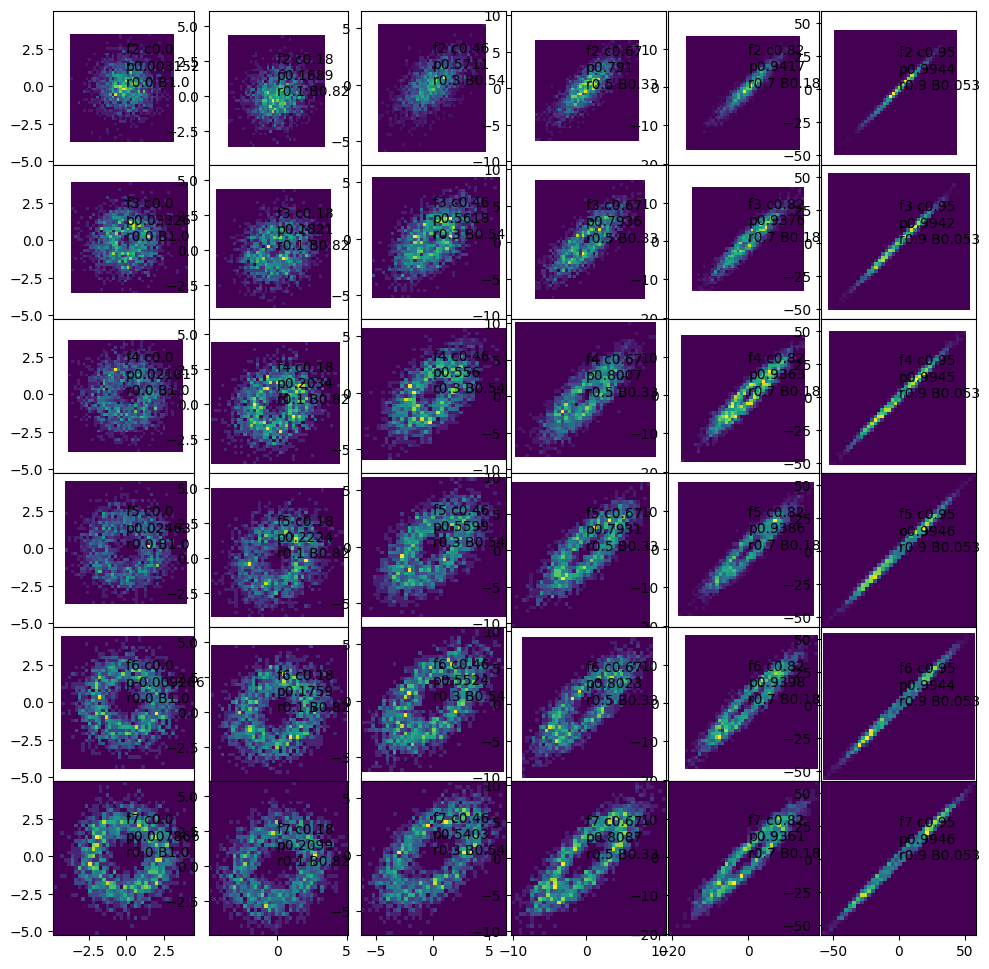

In [6]:
fig, ax = plt.subplots(6,6, sharex="col", sharey="col", figsize=(12,12))
s = 3
N = 2000
for mf in range(2,8):
    for a, r in enumerate([0.]+[0.1+0.2*i for i in range(5)]):
        B = (1-r)/(1+r)
        m = mf*s
        x = np.zeros((2,N))
        x[1,:] = np.sqrt(np.random.chisquare(mf,N))
        x = rotation(rotation(x, 2*np.pi*np.random.random(x.size//2),B),np.pi/4)
        lab = f"f{mf} c{1-B:.2}\np{pearsonr(*x)[0]:.4}\nr{r:.2} B{B:.2}"
        plt.sca(ax[mf-2,a])
        plt.hist2d(*x, bins=40)
        ax[mf-2,a].set_aspect('equal', 'box')
        plt.text(0,0,lab)
plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.show()

In [7]:
np.linalg.eig([[1,0.5],[0.5,1]]), 0.5/1.5, 

((array([1.5, 0.5]),
  array([[ 0.70710678, -0.70710678],
         [ 0.70710678,  0.70710678]])),
 0.3333333333333333)

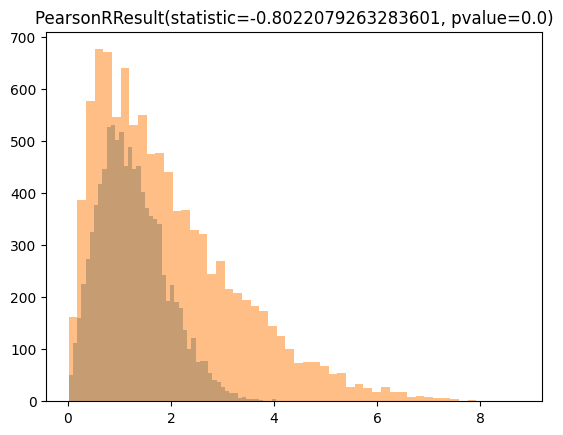

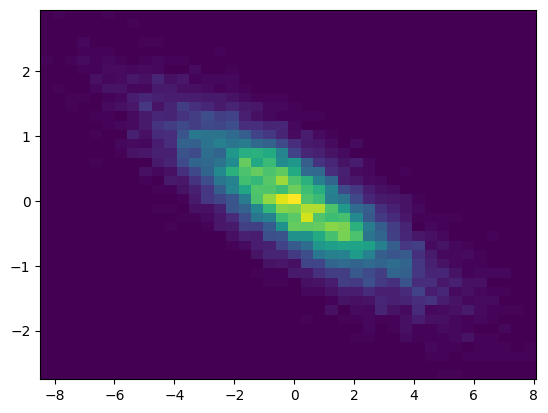

In [8]:
N=10000
x = np.zeros((2,N))
x[0,:] = np.sqrt(np.random.chisquare(2,N))
plt.hist(x[0], alpha=0.5, bins="auto")
x = rotation(rotation(x, 2*np.pi*np.random.random(x.size//2),1),np.pi/4,1/3)
# plt.hist(x[0], alpha=0.5, bins="auto")
# plt.hist(x[1], alpha=0.5, bins="auto")
plt.hist(np.sqrt(x[0]**2+x[1]**2), alpha=0.5, bins="auto")
plt.title(pearsonr(*x))
# plt.xlim(left=0, right=10)
plt.show()
plt.hist2d(*x, bins=40)
plt.show()

4.467723361209682
0 1.1601779755283648 1.9944382647385985
[1.99970331 0.05381658]
3.9566110310329345
0.3 1.1601779755283648 1.9877641824249166
[2.01568367 0.09948485]
2.550007919097884
0.7 1.10678531701891 1.8876529477196886
[2.07102553 0.381463  ]
2.0149763304605677
0.9 1.0533926585094548 1.7875417130144604
[2.23721637 0.66904615]
1.010154497860522
1 1.0 1.6874304783092327
[2.82599263 1.00082906]


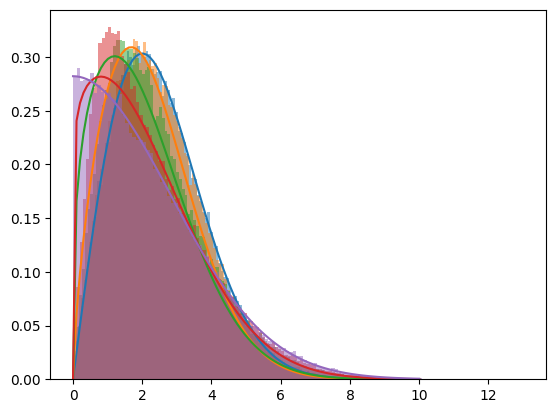

In [112]:
from scipy.stats import rayleigh, chi
from sympy.abc import y
from sympy import sqrt
from scipy.special import gamma
from scipy.optimize import curve_fit
# plt.plot(np.linspace(0,10,100), rayleigh.pdf(np.linspace(0,10,100),0,2))
# plt.hist(np.random.rayleigh(2,N), bins="auto", density=True)
N=100000
# def wierdist (x, sigma, rho):
#     factor = sigma * np.sqrt(1-rho**2)
#     return x/(sigma*factor)*np.exp(-x**2/factor**2/2)*np.i0(x**2*rho/factor**2)
def chidist (x, sigma, rho):
    k = (2-rho)
    y = x/sigma
    return chi.pdf(y,k)/sigma
kappas = np.linspace(1,7,900, endpoint=True)
mus = np.sqrt(2)*gamma((kappas+1)/2)/gamma(kappas/2)
for r in [0,0.3,0.7,0.9,1]:
    x = np.random.multivariate_normal([0,0], [[4,r*4],[r*4,4]],N).T
    distx = np.sqrt(x[0]**2+x[1]**2)
    p=plt.plot(np.linspace(0,10,100), chidist(np.linspace(0,10,100),2*(r**4*np.sqrt(2)+(1-r**4)),r))
    v, b, u = plt.hist(distx, alpha=0.5, bins="auto", density=True, color=p[0].get_color())
    print(b[np.argmax(v)]**2+1)
    # med = np.median(distx)
    # for sol in solut[2:]:
    #     print(med, sol.evalf(3,subs={y: med}))
    print(r, kappas[np.argmin(np.abs(mus-np.mean(distx/2/np.sqrt(2))))],kappas[np.argmin(np.abs(mus-np.mean(distx/2)))])
    print(curve_fit(chidist, b[:-1], v, (2,r))[0])
#plt.yscale("log")
plt.show()

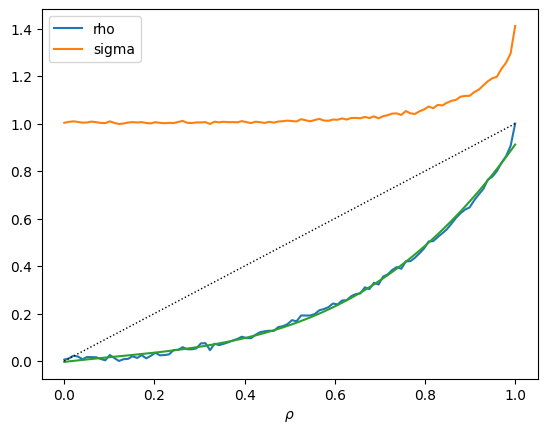

In [125]:
N=100000
# def wierdist (x, sigma, rho):
#     factor = sigma * np.sqrt(1-rho**2)
#     return x/(sigma*factor)*np.exp(-x**2/factor**2/2)*np.i0(x**2*rho/factor**2)
def chidist (x, sigma, rho):
    k = (2-rho)
    y = x/sigma
    return chi.pdf(y,k)/sigma
kappas = np.linspace(1,7,900, endpoint=True)
mus = np.sqrt(2)*gamma((kappas+1)/2)/gamma(kappas/2)
sigmas = np.zeros(100)
rhos = np.zeros(100)
for i in range(100):
    r = i/99
    x = np.random.multivariate_normal([0,0], [[4,r*4],[r*4,4]],N).T
    distx = np.sqrt(x[0]**2+x[1]**2)
    v, b = np.histogram(distx, bins="auto", density=True)
    s, r2 = curve_fit(chidist, b[:-1], v, (2,r))[0]
    sigmas[i] = s/2
    rhos[i] = r2


[ 1.89641171 -2.75699758  2.08725942 -0.31109813  0.02152467]


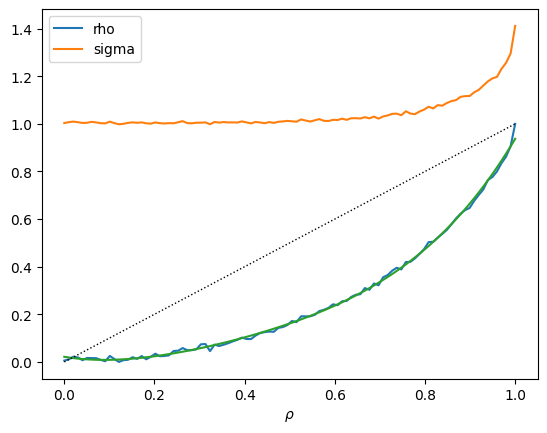

In [131]:
r0=np.arange(100)/99
corrhos = (rhos-np.min(rhos))/(np.max(rhos)-min(rhos))
plt.plot(r0, corrhos, label="rho")
plt.plot(r0, sigmas, label="sigma")
p=np.polyfit(np.arange(100)/99, corrhos,4)
plt.plot(r0, np.polyval(p, r0))
plt.plot([0,1],[0,1], ":k", lw=1)
plt.legend()
plt.xlabel(r"$\rho$")
print(p)
plt.show()

In [122]:
np.polyfit(np.arange(100)/99, rhos,2), np.pol

array([ 1.1308158 , -0.35644556,  0.08951769])

In [10]:
import sympy
A, x = sympy.symbols("A theta")

In [11]:
sympy.integrate(sympy.exp(A*sympy.sin(x)), (x,0, np.pi*2))

Integral(exp(A*sin(theta)), (theta, 0, 6.28318530717959))

In [92]:
from sympy.abc import n,x,y
sympy.summation(sympy.functions.special.bessel.besseli(n,2*np.pi), (n, 1, np.inf)).evalf()

224.191572435687

In [19]:
sympy.simplify(sympy.functions.special.bessel.besseli(0,x))

besseli(0, x)

In [93]:
solut = sympy.solve(sympy.sqrt(x*(1-2/(9*x))**3)-y,x)
solut

[y**2/3 - ((-y**2 - 2/3)**2 - 4/9)/(3*(2*y**2/3 + (-y**2 - 2/3)**3 + sqrt(-4*((-y**2 - 2/3)**2 - 4/9)**3 + (4*y**2/3 + 2*(-y**2 - 2/3)**3 + 16/27)**2)/2 + 8/27)**(1/3)) - (2*y**2/3 + (-y**2 - 2/3)**3 + sqrt(-4*((-y**2 - 2/3)**2 - 4/9)**3 + (4*y**2/3 + 2*(-y**2 - 2/3)**3 + 16/27)**2)/2 + 8/27)**(1/3)/3 + 2/9,
 y**2/3 - ((-y**2 - 2/3)**2 - 4/9)/(3*(-1/2 - sqrt(3)*I/2)*(2*y**2/3 + (-y**2 - 2/3)**3 + sqrt(-4*((-y**2 - 2/3)**2 - 4/9)**3 + (4*y**2/3 + 2*(-y**2 - 2/3)**3 + 16/27)**2)/2 + 8/27)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(2*y**2/3 + (-y**2 - 2/3)**3 + sqrt(-4*((-y**2 - 2/3)**2 - 4/9)**3 + (4*y**2/3 + 2*(-y**2 - 2/3)**3 + 16/27)**2)/2 + 8/27)**(1/3)/3 + 2/9,
 y**2/3 - ((-y**2 - 2/3)**2 - 4/9)/(3*(-1/2 + sqrt(3)*I/2)*(2*y**2/3 + (-y**2 - 2/3)**3 + sqrt(-4*((-y**2 - 2/3)**2 - 4/9)**3 + (4*y**2/3 + 2*(-y**2 - 2/3)**3 + 16/27)**2)/2 + 8/27)**(1/3)) - (-1/2 + sqrt(3)*I/2)*(2*y**2/3 + (-y**2 - 2/3)**3 + sqrt(-4*((-y**2 - 2/3)**2 - 4/9)**3 + (4*y**2/3 + 2*(-y**2 - 2/3)**3 + 16/27)**2)/2 + 8/27)**(

In [95]:
solut[0].evalf(subs={y: 4})

0.00442703269295563 + 0.0252821591579408*I

In [101]:
mus

array([0.79788456, 0.80345708, 0.80900209, 0.81451996, 0.820011  ,
       0.82547554, 0.83091392, 0.83632644, 0.84171341, 0.84707515,
       0.85241194, 0.85772409, 0.86301188, 0.8682756 , 0.87351552,
       0.87873193, 0.88392508, 0.88909525, 0.89424269, 0.89936766,
       0.90447041, 0.90955119, 0.91461025, 0.91964781, 0.92466412,
       0.92965941, 0.9346339 , 0.93958782, 0.94452139, 0.94943483,
       0.95432834, 0.95920214, 0.96405644, 0.96889143, 0.97370732,
       0.9785043 , 0.98328257, 0.98804231, 0.99278373, 0.99750699,
       1.00221228, 1.00689979, 1.01156968, 1.01622214, 1.02085733,
       1.02547541, 1.03007657, 1.03466096, 1.03922874, 1.04378007,
       1.04831511, 1.05283402, 1.05733693, 1.06182401, 1.06629541,
       1.07075126, 1.07519171, 1.0796169 , 1.08402698, 1.08842207,
       1.09280232, 1.09716786, 1.10151882, 1.10585534, 1.11017753,
       1.11448553, 1.11877945, 1.12305944, 1.12732559, 1.13157805,
       1.13581691, 1.14004231, 1.14425435, 1.14845315, 1.15263